# Notebook 5: fitting the maturities together

This controlled experiment reuses the saved synthetic inputs from Notebook 4. The executable cell rebuilds the independent control, joint fit, Figures 12–14 and offline explorer. Open `interactive/joint_density_surface.html` to explore the comparison. The first four notebooks are unchanged. Rerun this builder after changing the experiment to refresh the embedded figures.


# Linking the fitted maturity distributions
## Milestone 5: joint calendar constraints and an interval-level check
Joel Cerraga | Quant research project | Development version 0.5

**Status:** the joint synthetic fit passes the adjacent-maturity calendar check for all nonnegative strikes under the common-bin model, to a tolerance of $10^{-8}$. The same-solver independent control fails that check. The inputs, finite support and eight fitted maturities are unchanged. This is not an empirical SPX calibration or a fitted continuous-time surface.

### 1. Why the maturities must be linked

Milestone 4 fitted each maturity independently. Its marginal probability restrictions were satisfied, but some forward-normalised call values decreased as the horizon increased. Those failures occurred in extrapolated wings. Good agreement with prices inside the quote range therefore did not establish consistency across maturities.

As Gatheral and Jacquier explain in *Arbitrage-free SVI volatility surfaces* [12, §2.1], the martingale and convexity argument requires the normalised call ordering in Equation (14), under deterministic carry and proportional dividends. This milestone incorporates that ordering in the estimator. Their SVI parameterisation is not used: the project retains its histogram representation and exact interval-payoff integrals.

As Bahra (1997) explains in his Bank of England working paper [1, §§2.1–2.2], the extracted distribution is risk-neutral. Linking its maturities does not make it a physical-probability forecast. The improvement sought here is internal consistency of the fitted option-price family.

### 2. A common coordinate system

The original physical support is $[0.3F(T),2.2F(T)]$. Dividing terminal levels by the forward places every maturity on common edges $u_0=0.3,\ldots,u_J=2.2$, with $J=120$ equal intervals of width $\Delta u$. Write $F_m=F(T_m)$ and let $w_{mj}$ be the probability assigned to interval $j$ at maturity $m$:

$$\widehat g_m(x)=\sum_{j=1}^{J}\frac{w_{mj}}{\Delta u}\,\mathbf 1_{[u_{j-1},u_j)}(x),\qquad \widehat f_Q(s;T_m)=\frac{1}{F_m}\widehat g_m\!\left(\frac{s}{F_m}\right).\tag{16}$$

Here, $x=s/F_m$ and $\widehat g_m$ are dimensionless; $\widehat f_Q$ retains units of inverse index points. Equation (16) is the project's change of variables in Equation (9), with the forward normalisation in Equation (13). The factor $1/F_m$ is necessary to preserve probability under the change of coordinate.

Define the bin centre $\bar u_j=(u_{j-1}+u_j)/2$. Unit mass and the supplied forward mean become $\sum_j w_{mj}=1$ and $\sum_j\bar u_j w_{mj}=1$. They are the same restrictions as Equation (10), expressed in common coordinates.

For one unit of uniform probability in interval $j$, write $B_j(\kappa)=(\Delta u)^{-1}\int_{u_{j-1}}^{u_j}(x-\kappa)_+\,dx$. The row vector $\mathbf B(\kappa)$ contains these exact, dimensionless payoff integrals. Consequently, $\overline C(\kappa,T_m)=\mathbf B(\kappa)\mathbf w_m$; this follows directly from Equations (11), (13) and (16).

### 3. The joint estimation problem

Let $\ell_m(\mathbf w_m)$ denote the complete per-maturity objective in Equation (12), including the squared errors divided by $F_m^2$ and the smoothing penalty. The joint programme is:

$$\begin{aligned}
\min_{\mathbf w_1,\ldots,\mathbf w_M}\quad &\sum_{m=1}^{M}\ell_m(\mathbf w_m)\\
\text{subject to}\quad &w_{mj}\geq0,\quad \mathbf 1^\top\mathbf w_m=1,\quad \bar{\mathbf u}^{\top}\mathbf w_m=1,\\
&\mathbf B(\kappa)(\mathbf w_{m+1}-\mathbf w_m)\geq0,
\quad \kappa\in\mathcal K_m,\quad m=1,\ldots,M-1.
\end{aligned}\tag{17}$$

There are $M=8$ horizons and 960 probability weights. The sets $\mathcal K_m$ contain calendar-constraint locations and are expanded when the interval check finds a failure. There is no penalty coupling neighbouring maturities: only the ordering inequalities link their fits. The existing smoothing penalty remains $10^{-6}$ within each slice.

As Boyd and Vandenberghe describe in *Convex Optimization* [11, §§4.4, 6.3], a convex quadratic objective with affine constraints can be handled as a quadratic programme. Equation (17) is this project's particular formulation. As Stellato and co-authors describe in their OSQP paper [13, §§1.1, 3.4], the solver addresses such programmes using residual-based numerical stopping criteria. Solver termination is therefore followed by separate probability and calendar checks.

Changing both the solver and the constraints would make attribution ambiguous. The comparison consequently contains three cases: the saved Milestone 4 SLSQP fit; an independent OSQP control with the same objective; and the joint OSQP fit. The last two differ only in their calendar constraints. Both start from the saved independent weights. The known density is used for evaluation, not supplied as a target or a constraint.

### 4. Why checking bin boundaries is insufficient

Within one histogram bin, the normalised call price is quadratic in strike. Its difference across maturities is also quadratic and may dip below zero between two nonnegative endpoint values. Adding constraints only at bin boundaries can therefore miss a violation.

For an adjacent pair, define $\delta_{mj}=w_{m+1,j}-w_{mj}$ and $\Delta_m(\kappa)=\overline C(\kappa,T_{m+1})-\overline C(\kappa,T_m)$. On interval $j$, exact integration of the histogram payoff gives:

$$\Delta_m(u_{j-1}+z)=\Delta_m(u_{j-1})-z\sum_{\ell=j}^{J}\delta_{m\ell}+\frac{\delta_{mj}}{2\Delta u}z^2,\qquad 0\leq z\leq\Delta u.\tag{18}$$

The linear coefficient is minus the difference in upper-tail probabilities at the left edge. The curvature is the difference in density heights. Differentiating Equation (18) yields a possible interior minimum:

$$z^*_{mj}=\Delta u\,\frac{\sum_{\ell=j}^{J}\delta_{m\ell}}{\delta_{mj}},\qquad \delta_{mj}>0,\quad 0<z^*_{mj}<\Delta u.\tag{19}$$

If those conditions do not hold, the bin's minimum is attained at an endpoint. Below the common support the gap is linear, so checking zero and the first edge suffices; above the support both model calls are zero. Evaluating all endpoints and eligible interior minima therefore covers every nonnegative strike for each adjacent pair in this representation. Equations (18)–(19) are project derivations from the histogram payoff, not formulae attributed to the SVI paper.

The implementation first constrains the 119 interior edges for each of seven adjacent pairs: 833 calendar rows. It then locates the minimum gaps, adds offending interior locations and refits. Five solves increase the row count to 858. The first boundary-constrained solve still has a minimum gap of approximately $-3.14\times10^{-7}$; the final gap is approximately $-8.56\times10^{-10}$. This demonstrates why the additional check matters even after calendar inequalities have been introduced.

The published acceptance tolerance is $10^{-8}$ in normalised call value. Refinement targets $10^{-9}$ to leave a margin within that tolerance. This is an analytical calculation of candidate minimum locations in floating-point arithmetic, not a formal interval-arithmetic certificate. It covers the supplied discrete maturities, not the intermediate times suggested by a rendered sheet.

A separate numerical test uses two non-lognormal distributions with unit mass and mean one. Every bin-boundary gap is nonnegative, yet an interior gap equals $-0.009375$ at $\kappa=0.875$. The checker detects it and the joint solver removes the failure to tolerance. This guards against an implementation that only appears to work on the lognormal benchmark.

### 5. Comparing the results

The saved synthetic quote files are reused without changing their noise, strike coverage, forwards or discount factors. Each horizon still contains 81 supplied prices and 80 withheld clean prices. A pooled RMSE gives each withheld price equal weight; the reported mean density error gives each maturity equal weight.



In [1]:
from run_joint import main
from build_joint_html import main as build_explorer
result = main()
explorer = build_explorer()


{
  "cases": {
    "legacy": {
      "sampled_violations": 2762,
      "minimum_continuous_gap": -0.00019080816595251198,
      "pooled_withheld_rmse": 0.1195132692009756,
      "mean_density_l1": 0.03515729066603747
    },
    "control": {
      "sampled_violations": 2763,
      "minimum_continuous_gap": -0.0001908355394987363,
      "pooled_withheld_rmse": 0.11951319494677509,
      "mean_density_l1": 0.035157564270130295
    },
    "joint": {
      "sampled_violations": 0,
      "minimum_continuous_gap": -8.561045191784403e-10,
      "pooled_withheld_rmse": 0.119153186754386,
      "mean_density_l1": 0.03516244090598916
    }
  },
  "joint_objective_increase_percent": 0.0399428912398081,
  "joint_solver": {
    "name": "OSQP",
    "version": "1.1.3",
    "enforce_calendar": true,
    "eps_abs": 1e-10,
    "eps_rel": 1e-10,
    "objective_scale": 1000000.0,
    "calendar_tolerance": 1e-08,
    "objective_sum": 2.984259662230008e-08,
    "refinement_target": 1e-09,
    "refinement_rou

Table 9. Calendar consistency and recovery accuracy across the three fitting cases. Grid counts use 13,307 adjacent-pair comparisons and tolerance $10^{-8}$. The minimum gap comes from the interval-level check. Price RMSE is in index points; gap and density $L_1$ are dimensionless.

| Fit | Grid violations | Minimum calendar gap | Pooled withheld-price RMSE | Mean density $L_1$ |
|---|---:|---:|---:|---:|
| Saved independent SLSQP | 2,762 | $-1.90808\times10^{-4}$ | 0.119513 | 0.035157 |
| Independent OSQP control | 2,763 | $-1.90836\times10^{-4}$ | 0.119513 | 0.035158 |
| Joint OSQP | 0 | $-8.56105\times10^{-10}$ | 0.119153 | 0.035162 |

The extra sampled violation in the OSQP control reflects a small solver-dependent change near the counting threshold; it is not a new input dataset. The controlled comparison is 2,763 versus zero. These counts are correlated strike-grid checks, not independent trading opportunities or probabilities.

Table 10. Recovery accuracy by synthetic horizon. RMSE compares against withheld clean prices; the density error is Equation (15) on the finite support.

| Horizon (days) | Control RMSE | Joint RMSE | Control density $L_1$ | Joint density $L_1$ |
|---|---:|---:|---:|---:|
| 30 | 0.127807 | 0.127248 | 0.058292 | 0.058580 |
| 60 | 0.109230 | 0.108049 | 0.042718 | 0.043281 |
| 90 | 0.131872 | 0.131690 | 0.036594 | 0.037064 |
| 120 | 0.096014 | 0.095934 | 0.030899 | 0.031052 |
| 180 | 0.083350 | 0.083266 | 0.027399 | 0.027311 |
| 240 | 0.149516 | 0.148945 | 0.026954 | 0.026008 |
| 300 | 0.105392 | 0.105271 | 0.025824 | 0.025642 |
| 365 | 0.137777 | 0.137723 | 0.032580 | 0.032363 |

Calendar consistency improves markedly, while recovery accuracy changes little. Withheld-price RMSE decreases slightly, but mean density $L_1$ increases slightly. The input-price RMSE also increases, from approximately 0.261370 to 0.261377 index points. The total fitting objective rises by approximately 0.03994%, as expected when additional restrictions reduce the feasible set. This experiment therefore supports a consistency improvement, not a general claim of better density estimation.

### 6. Interpreting the figures



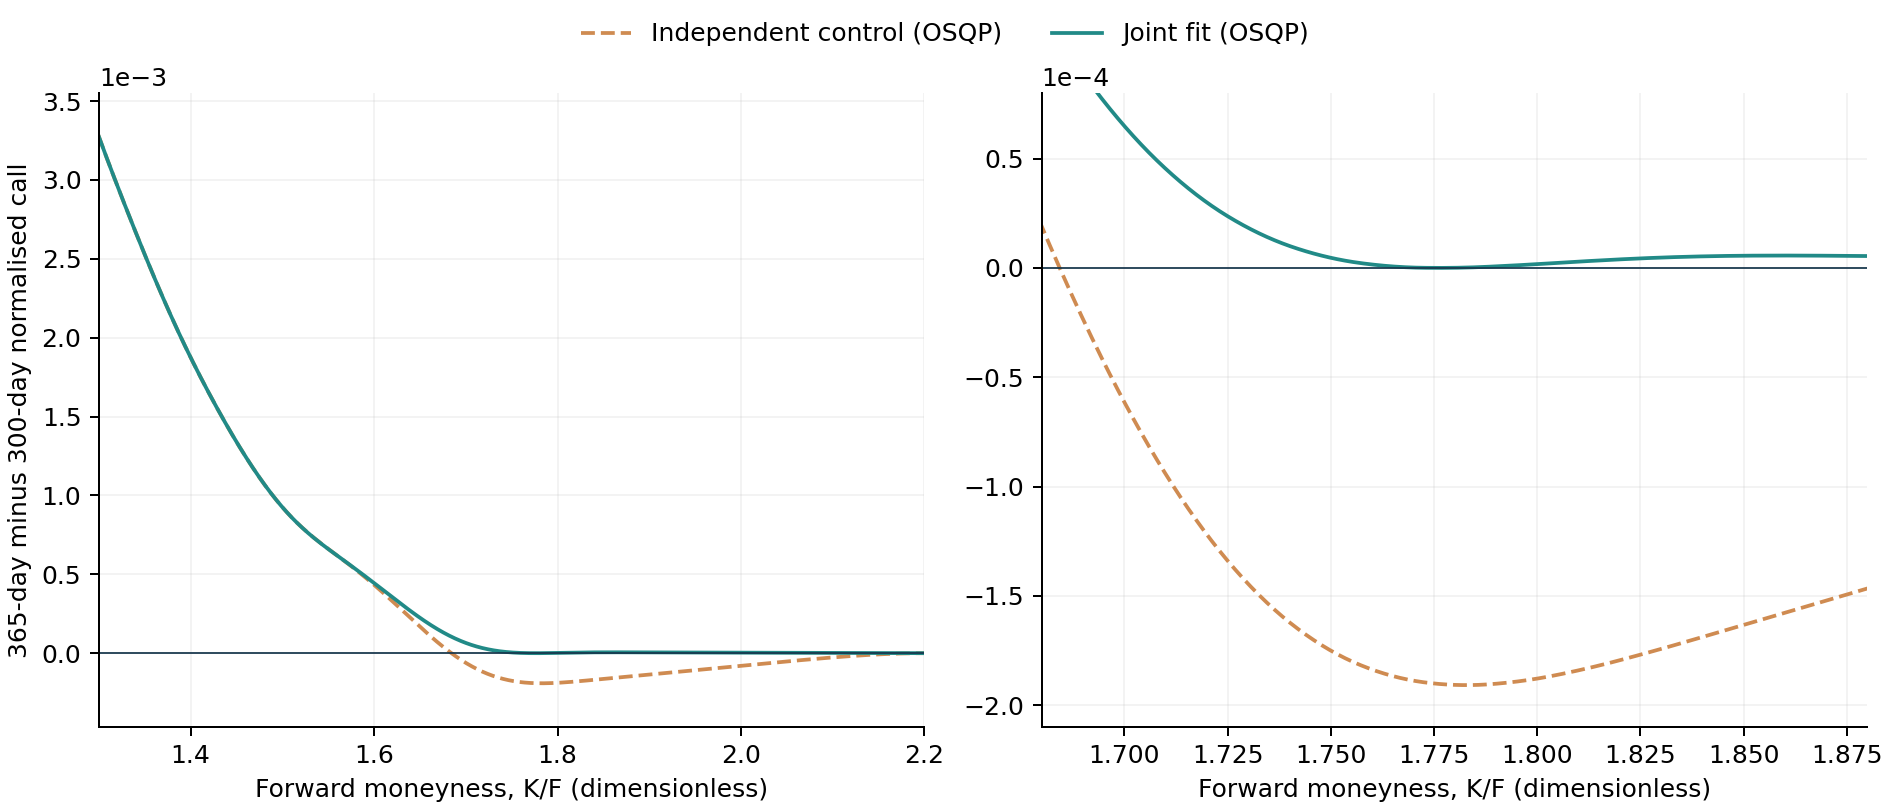




Figure 12. Difference between 365-day and 300-day forward-normalised call values under the independent control and joint fit. The left panel shows the upper-strike wing; the right panel enlarges the interval containing the control's deepest decrease. A negative value violates the required maturity ordering when its magnitude exceeds the stated tolerance. Values are dimensionless.

Figure 12 shows that the fitted change is concentrated where the control previously failed. The final small negative numerical residual is far below the scale of this plot; the saved diagnostic, rather than visual inspection alone, establishes acceptance at the stated tolerance.



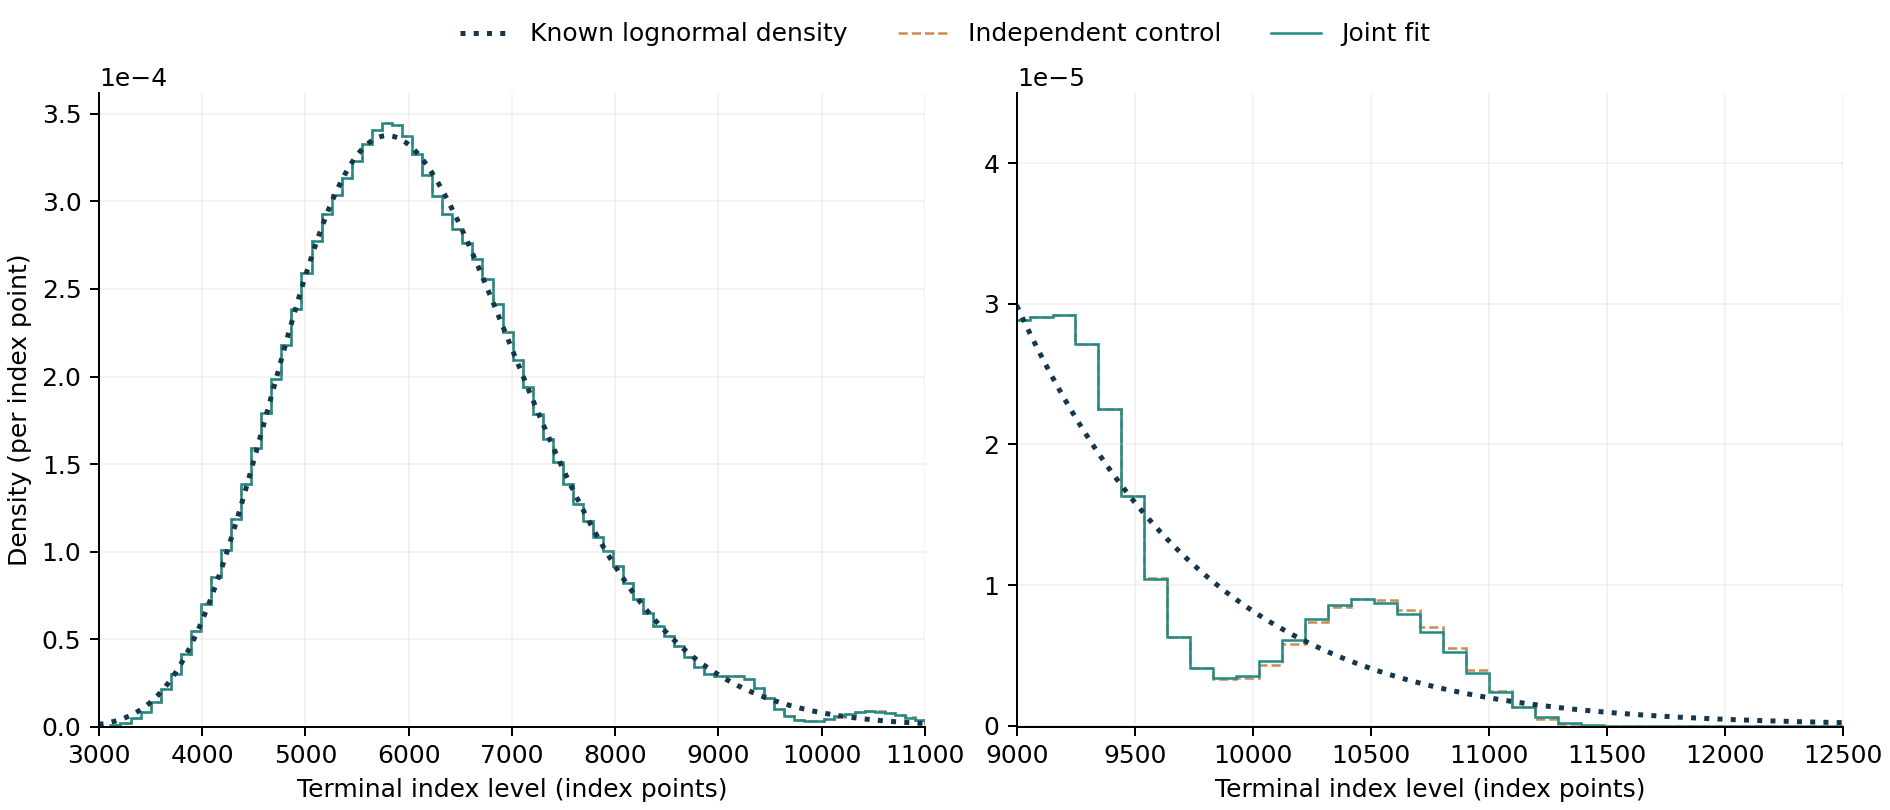




Figure 13. Known density, independent control and joint fit at 365 days. The main panel covers terminal levels 3,000–11,000; the second panel enlarges the right tail over 9,000–12,500. Fitted curves show the actual histogram steps. Density is measured per index point.

Figure 13 explains why calendar consistency and density accuracy must be assessed separately. The central shapes nearly overlap, while a small fitted tail bump remains beyond the largest supplied 365-day strike, approximately 10,143 points. The joint restriction does not supply missing tail observations. This feature is an observed estimation artefact relative to the known benchmark, not evidence of a market tail event.



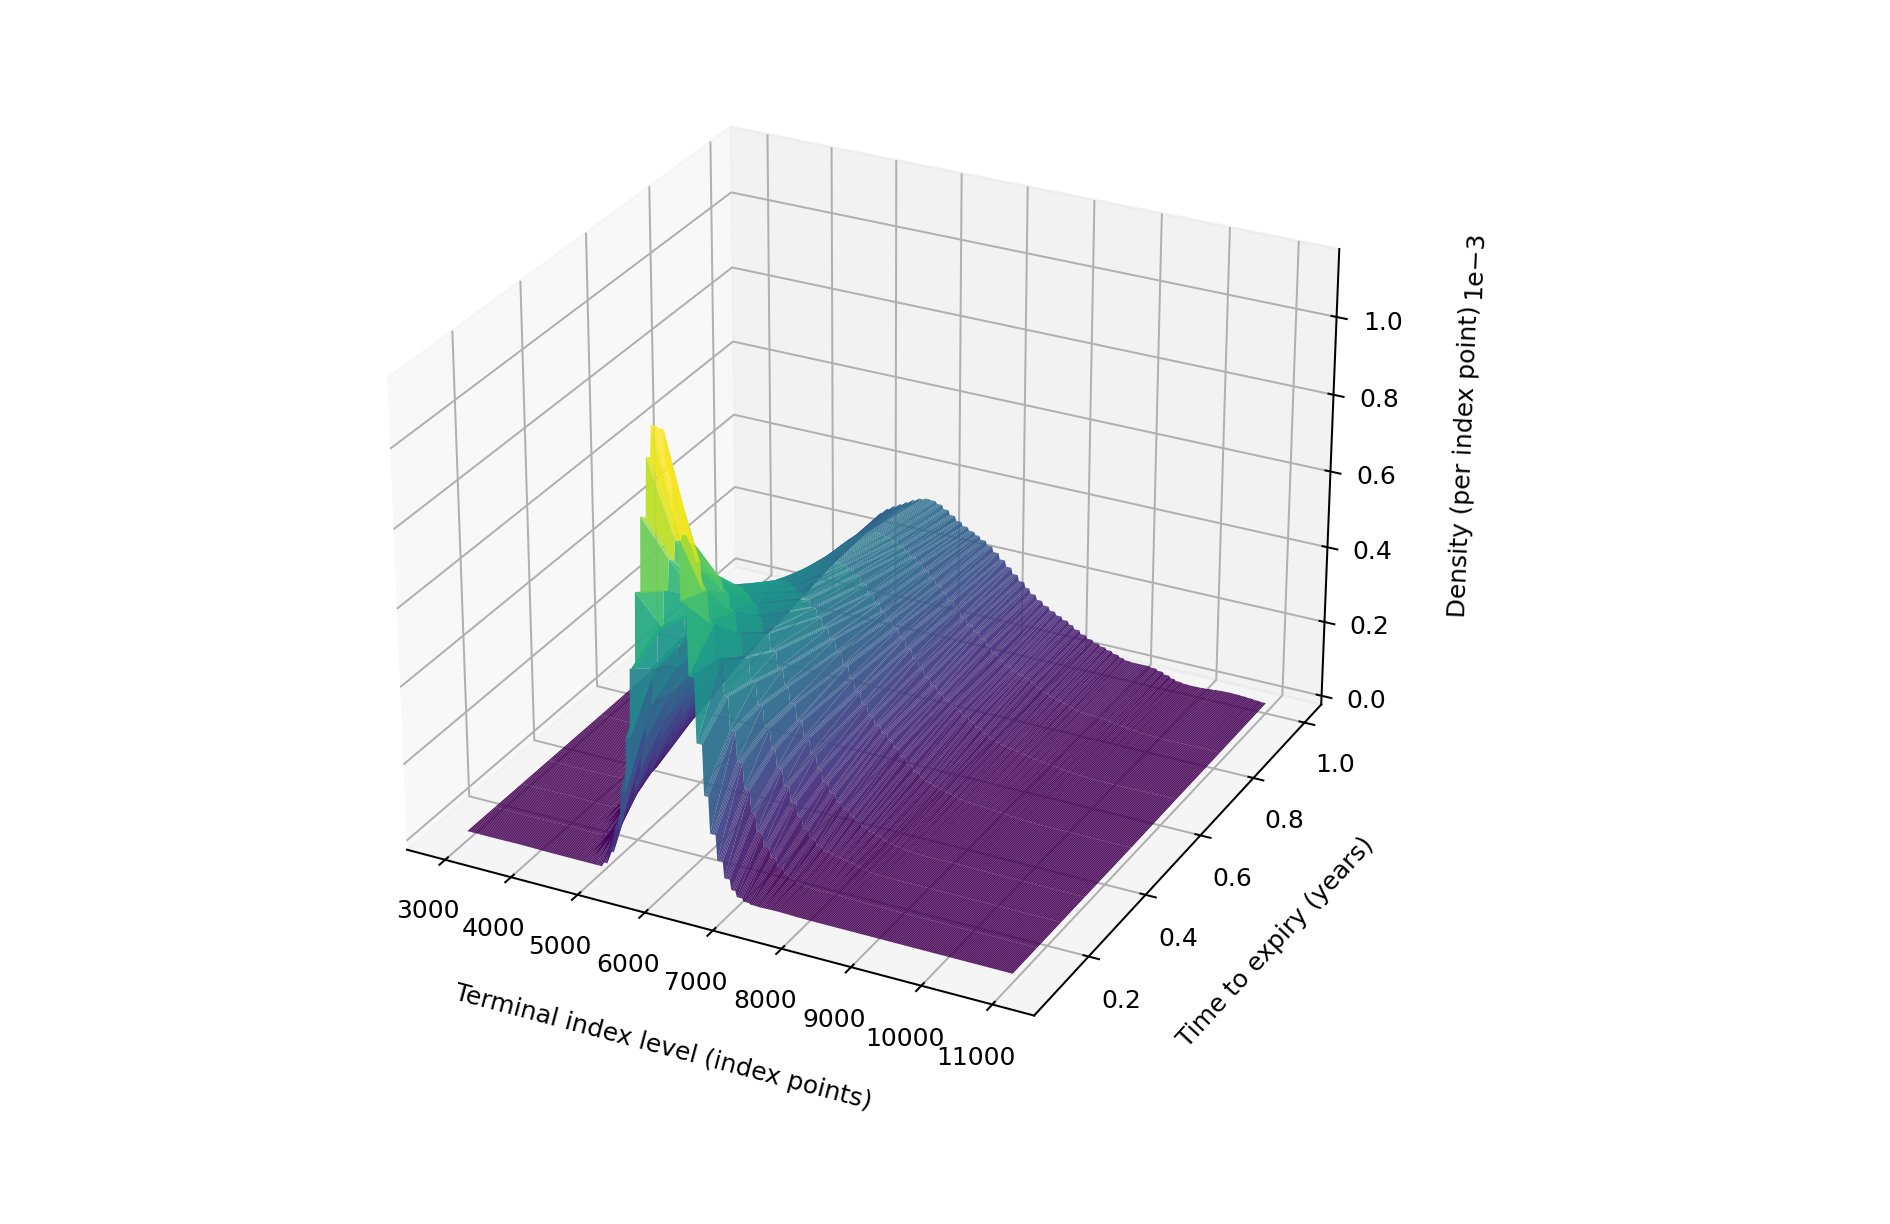




Figure 14. Jointly fitted synthetic risk-neutral densities at eight horizons. The axes are terminal index level, expiry horizon in years and density per index point. Connecting facets are graphical joins only; they do not establish an estimated or calendar-consistent distribution at an intermediate maturity.

Open [the joint-fit interactive companion](interactive/joint_density_surface.html) for rotation, zoom, hover values, maturity selection and play/pause. Its surface selector compares the joint fit, independent control and known density. The linked 2D panel retains all three curves, and a separate calendar panel displays the fixed 300-to-365-day comparison. Captions remain below the plots. The display window is cropped without renormalising the saved probabilities.

### 7. Numerical limits and the next research questions

OSQP 1.1.3 uses absolute and relative stopping settings of $10^{-10}$. The quadratic objective is multiplied by $10^6$ for solver scaling; this does not change the mathematical minimiser. Relative stopping thresholds depend on problem scale, as described by Stellato and co-authors [13, §3.4], so those settings must not be presented as bounds on every reported residual. Full solver histories are saved in `results/joint_validation.json`.

All five solves report `solved`. The optional polishing step was not accepted, so the returned main iterates are used; the results are not described as polished solutions. The final maximum mass error is approximately $8.44\times10^{-15}$, the maximum normalised-mean error is $5.11\times10^{-15}$, and the minimum raw bin mass is $-1.57\times10^{-12}$. These tiny signed values are retained and reported as numerical residuals. No probabilities are clipped or renormalised. The runner rejects failed solver status or probability checks and stops if calendar refinement cannot meet its target.

Finite support, resolution and regularisation still influence the answer. The next numerical investigation should vary those choices, including on non-lognormal benchmarks, before treating extrapolated tails as reliable. In particular, this milestone has not established robustness of tail probabilities or moments across alternative supports.

The candidate market snapshot remains unsuitable for calibration for the reasons in `data_access_status.md`. Verified observation timestamps, usable quote fields and settlement horizons are still required. Historical-date animation remains planned once suitable snapshots exist; the present play control sweeps maturities at one synthetic valuation setup.

The first four notebooks are preserved. The Figure 4 explanation remains below its figure and caption. `paper_registers.md` now tracks Figures 1–14, Tables 1–10 and Equations (1)–(19), alongside abbreviations and symbols. The title page, abstract, contents and page-numbered lists remain part of the final combined paper.

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England, Working Paper No. 66, §§2.1–2.2. [Full paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[11] S. Boyd and L. Vandenberghe (2004), *Convex Optimization*. Cambridge University Press, §§4.4, 6.3. [Author-hosted book](https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf).

[12] J. Gatheral and A. Jacquier, “Arbitrage-free SVI volatility surfaces,” *Quantitative Finance*, vol. 14, no. 1, pp. 59–71; first published online 2013. [doi:10.1080/14697688.2013.819986](https://doi.org/10.1080/14697688.2013.819986). Consulted [author preprint](https://arxiv.org/abs/1204.0646v4), §2.1.

[13] B. Stellato, G. Banjac, P. Goulart, A. Bemporad and S. Boyd (2020), “OSQP: An Operator Splitting Solver for Quadratic Programs,” *Mathematical Programming Computation*, vol. 12, no. 4, pp. 637–672. [doi:10.1007/s12532-020-00179-2](https://doi.org/10.1007/s12532-020-00179-2). [Author publication page](https://web.stanford.edu/~boyd/papers/osqp.html); consulted [author preprint](https://arxiv.org/abs/1711.08013v4), §§1.1, 3.4, 4.
